##### 导入一些需要用到的三方库

In [ ]:
import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline 
import plotly.express as px
import time 

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from nltk.tokenize import RegexpTokenizer
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline

from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

from bs4 import BeautifulSoup
from selenium import webdriver
import networkx as nx
import pickle

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 加载数据集
phish_data = pd.read_csv('./phishing_site_urls.csv')

In [3]:
phish_data.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [4]:
phish_data.tail()

,URL,Label
549341,23.227.196.215/,bad
549342,apple-checker.org/,bad
549343,apple-iclods.org/,bad
549344,apple-uptoday.org/,bad
549345,apple-search.info,bad


In [5]:
phish_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


* **关于这个数据集**
* 数据包含549346个唯一条目
* 有两列
* 标签列是预测栏，有2个类别：
    * A. Good - 这意味着网址不包含恶意的东西和**这个网站不是一个钓鱼网站**
    * B. Bad - 这意味着url包含恶意的东西和**这个网站是钓鱼网站**
* 数据集中没有缺失值

In [ ]:
phish_data.isnull().sum()

URL      0
Label    0
dtype: int64

**因为这是分类问题，所以让我们看看这些类是平衡的还是不平衡的**

In [ ]:
label_counts = pd.DataFrame(phish_data.Label.value_counts())

In [ ]:
# 可视化该数据，展现出钓鱼url和非钓鱼的url
print("原列的实际名字：", phish_data.Label.name)
print("label_counts 的列名：", label_counts.columns.tolist())
fig = px.bar(label_counts, x=label_counts.index, y=label_counts['count'])
fig.show()

原列的实际名字： Label
label_counts 的列名： ['count']


### 预处理
* **现在有了数据，我们必须对 url 进行矢量化。我使用了 CountVectorizer 并使用 tokenizer 收集单词，因为url中的单词比其他单词更重要，例如 "virtus"，".exe"，".dat"等。让我们把 url 转换成矢量形式。**

#### RegexpTokenizer
* 使用正则表达式拆分字符串的记号赋予器，该表达式匹配记号或记号之间的分隔符。
* RegexpTokenizer：是 Python 的nltk（自然语言处理库）中的一个工具类，用于根据正则表达式对文本进行 “分词”（将文本拆分成有意义的子串，称为 “token”）。
* 正则表达式 r'[A-Za-z]+'：表示 “匹配一个或多个连续的大小写字母”（[A-Za-z] 匹配单个字母，+ 表示 “一次或多次”）。
* 作用：创建一个分词器，它会从文本中只提取由字母组成的序列，忽略数字、符号（如@、:、/等）、空格等非字母字符。
* 例如：对 URL https://fake-bank123.com/login 进行分词，会得到 ['https', 'fake', 'bank', 'com', 'login']（过滤了://、-、123、/等非字母字符）。

In [ ]:
tokenizer = RegexpTokenizer(r'[A-Za-z]+')

In [ ]:
# 第一个 URL
phish_data.URL[0]

'nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526'

In [ ]:
# 使用这个正则分词器对 URL 的第一行进行分词
tokenizer.tokenize(phish_data.URL[0])

['nobell',
 'it',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'login',
 'SkyPe',
 'com',
 'en',
 'cgi',
 'bin',
 'verification',
 'login',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'index',
 'php',
 'cmd',
 'profile',
 'ach',
 'outdated',
 'page',
 'tmpl',
 'p',
 'gen',
 'failed',
 'to',
 'load',
 'nav',
 'login',
 'access']

In [16]:
print('正在进行单词分词处理 ...')
t0= time.perf_counter()
# 对数据中所有 URL 进行批量分词处理
phish_data['text_tokenized'] = phish_data.URL.map(lambda t: tokenizer.tokenize(t))
t1 = time.perf_counter() - t0
print('总耗时：',t1 ,'sec')

正在进行单词分词处理 ...
总耗时： 1.955998900004488 sec


In [ ]:
# 展示 5 行分词的效果
phish_data.sample(5)

,URL,Label,text_tokenized
484189,memo.extremetanningofsarasota.com/1sc9khy2mg\n...,bad,"[memo, extremetanningofsarasota, com, sc, khy,..."
82639,tog.acm.org/resources/bib/,good,"[tog, acm, org, resources, bib]"
275460,amazon.com/Hire-Rob-Lowe/dp/B00000J2LF,good,"[amazon, com, Hire, Rob, Lowe, dp, B, J, LF]"
118711,melodienicolemusic.com/wp-admin/js/admin/dh/dh...,bad,"[melodienicolemusic, com, wp, admin, js, admin..."
496859,mphtadhci5mrdlju.tor2web.org/,bad,"[mphtadhci, mrdlju, tor, web, org]"


#### SnowballStemmer
* 作用：是 Python nltk 库中的词干提取工具，基于 “Snowball 语言”（一种轻量级字符串处理语言），能将英语单词还原为词根（词干）
* 例如：banking→bank、payment→pay，通过统一词根减少词汇数量，提升后续分析的效率。
* 初始化：stemmer = SnowballStemmer("english") 选择英语词干提取规则。
* 通过词干提取，将 URL 中的单词归一化到词根，减少词汇的 “表面多样性”（如同一词根的不同变形），让后续的钓鱼 URL 检测模型更关注语义核心，同时降低特征维度，提升训练效率。

In [18]:
stemmer = SnowballStemmer("english") # choose a language

In [19]:
print('开启提取词根 ...')
t0= time.perf_counter()
phish_data['text_stemmed'] = phish_data['text_tokenized'].map(lambda l: [stemmer.stem(word) for word in l])
t1= time.perf_counter() - t0
print('总耗时：',t1 ,'sec')

开启提取词根 ...
总耗时： 36.39485660000355 sec


In [20]:
# 随机抽样 5 个查看效果
phish_data.sample(5)

,URL,Label,text_tokenized,text_stemmed
275134,amazon.com/Football-American-Coaching-Sports-B...,good,"[amazon, com, Football, American, Coaching, Sp...","[amazon, com, footbal, american, coach, sport,..."
338349,findticketsfast.com/NCAA_College_Football/Texa...,good,"[findticketsfast, com, NCAA, College, Football...","[findticketsfast, com, ncaa, colleg, footbal, ..."
482475,zipmap.net/,good,"[zipmap, net]","[zipmap, net]"
128715,lppm.unsrat.ac.id/administrator/components/com...,bad,"[lppm, unsrat, ac, id, administrator, componen...","[lppm, unsrat, ac, id, administr, compon, com,..."
453666,tvguide.com/celebrities/julia-robinson/159273,good,"[tvguide, com, celebrities, julia, robinson]","[tvguid, com, celebr, julia, robinson]"


#### 为什么要进行字符串拼接？
* 在自然语言处理（尤其是文本分类，如钓鱼 URL 检测）中，很多特征提取方法（如词袋模型、TF-IDF、CountVectorizer等）或模型（如部分文本分类器）需要输入的是连续的字符串（而非分散的单词列表）。
* 例如：
* 后续若用TfidfVectorizer提取 URL 的词频特征，需要输入字符串（如'https fake bank com login'），才能识别 “单词” 并计算权重。
* 拼接后的字符串也更便于人工查看和验证预处理效果（相比列表形式更直观）。
* 假设text_stemmed列的某行为：['http', 'secure', 'paypal', 'org', 'verif']（词干化后，verify→verif）
* 经过代码处理后，text_sent列对应行为：'http secure paypal org verif'
* 这一步是预处理流程的 “格式化收尾”，将分散的词干整合为连续字符串，为后续的特征提取（如计算词频、生成向量） 和模型输入做好准备，确保后续步骤能正确识别和处理 URL 中的核心词汇特征。

In [ ]:
print('正在进行单词拼接处理 ...')
t0= time.perf_counter()
# 核心逻辑：将 “词干化后的单词列表” 转换为 “用空格分隔的字符串”
phish_data['text_sent'] = phish_data['text_stemmed'].map(lambda l: ' '.join(l))
t1= time.perf_counter() - t0
print('总耗时：',t1 ,'sec')

正在进行单词拼接处理 ...
Time taken 0.20547259999875678 sec


In [22]:
phish_data.sample(5)

,URL,Label,text_tokenized,text_stemmed,text_sent
304467,cimcorefrigeration.com/ag_prj_mario_tremblay.asp,good,"[cimcorefrigeration, com, ag, prj, mario, trem...","[cimcorefriger, com, ag, prj, mario, tremblay,...",cimcorefriger com ag prj mario tremblay asp
298043,canada.com/cityguides/montreal/story.html?id=3...,good,"[canada, com, cityguides, montreal, story, htm...","[canada, com, cityguid, montreal, stori, html,...",canada com cityguid montreal stori html id fa ...
388940,michiganbusiness.us/listhotelsincity.php?nic=R...,good,"[michiganbusiness, us, listhotelsincity, php, ...","[michiganbusi, us, listhotelsinc, php, nic, re...",michiganbusi us listhotelsinc php nic reed citi
315420,disneyxd.ca/,good,"[disneyxd, ca]","[disneyxd, ca]",disneyxd ca
4053,www.palimpalem.com/3/COMUNIDAD/body2.html,bad,"[www, palimpalem, com, COMUNIDAD, body, html]","[www, palimpalem, com, comunidad, bodi, html]",www palimpalem com comunidad bodi html


### 可视化
**1. 使用词云来可视化一些关键词汇**

In [23]:
# 切片分类
bad_sites = phish_data[phish_data.Label == 'bad']
good_sites = phish_data[phish_data.Label == 'good']

In [24]:
bad_sites.head()

,URL,Label,text_tokenized,text_stemmed,text_sent
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [25]:
good_sites.head()

,URL,Label,text_tokenized,text_stemmed,text_sent
18231,esxcc.com/js/index.htm?us.battle.net/noghn/en/...,good,"[esxcc, com, js, index, htm, us, battle, net, ...","[esxcc, com, js, index, htm, us, battl, net, n...",esxcc com js index htm us battl net noghn en r...
18232,wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË\nÓ6...,good,"[www, eira, nvinip, ncH, wV, yDaH, yE, u, rT, ...","[www, eira, nvinip, nch, wv, ydah, ye, u, rt, ...",www eira nvinip nch wv ydah ye u rt u g m i xz...
18233,'www.institutocgr.coo/web/media/syqvem/dk-óij...,good,"[www, institutocgr, coo, web, media, syqvem, d...","[www, institutocgr, coo, web, media, syqvem, d...",www institutocgr coo web media syqvem dk ij r ...
18234,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,good,"[Y, ko, D, l, qt]","[y, ko, d, l, qt]",y ko d l qt
18236,ruta89fm.com/images/AS@Vies/1i75cf7b16vc<Fd16...,good,"[ruta, fm, com, images, AS, Vies, i, cf, b, vc...","[ruta, fm, com, imag, as, vie, i, cf, b, vc, f...",ruta fm com imag as vie i cf b vc f d b g sd v...


* 创建一个函数来可视化url中的重要键 

In [ ]:
def plot_wordcloud(text, mask=None, max_words=400, max_font_size=120, figure_size=(30.0, 20.0), 
                   title = None, title_size=40, image_color=False):
    stopwords = set(STOPWORDS)
    more_stopwords = {'com','http'}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(background_color='white',
                    stopwords = stopwords,
                    max_words = max_words,
                    max_font_size = max_font_size, 
                    random_state = 42,
                    mask = mask,
                    scale=3)
    wordcloud.generate(text)
    
    plt.figure(figsize=figure_size)
    if image_color:
        image_colors = ImageColorGenerator(mask);
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear");
        plt.title(title, fontdict={'size': title_size,  
                                  'verticalalignment': 'bottom'})
    else:
        plt.imshow(wordcloud);
        plt.title(title, fontdict={'size': title_size, 'color': 'green', 
                                  'verticalalignment': 'bottom'})
    plt.axis('off');
    plt.tight_layout()  
# 掩码图片的路径
# d = './masks/masks-wordclouds/'

In [45]:
# 获取“正常URL”的文本列（之前拼接的词干字符串，如 'http secure bank com'）
data = good_sites.text_sent
# 重置索引（避免索引混乱影响文本拼接）
data.reset_index(drop=True, inplace=True)

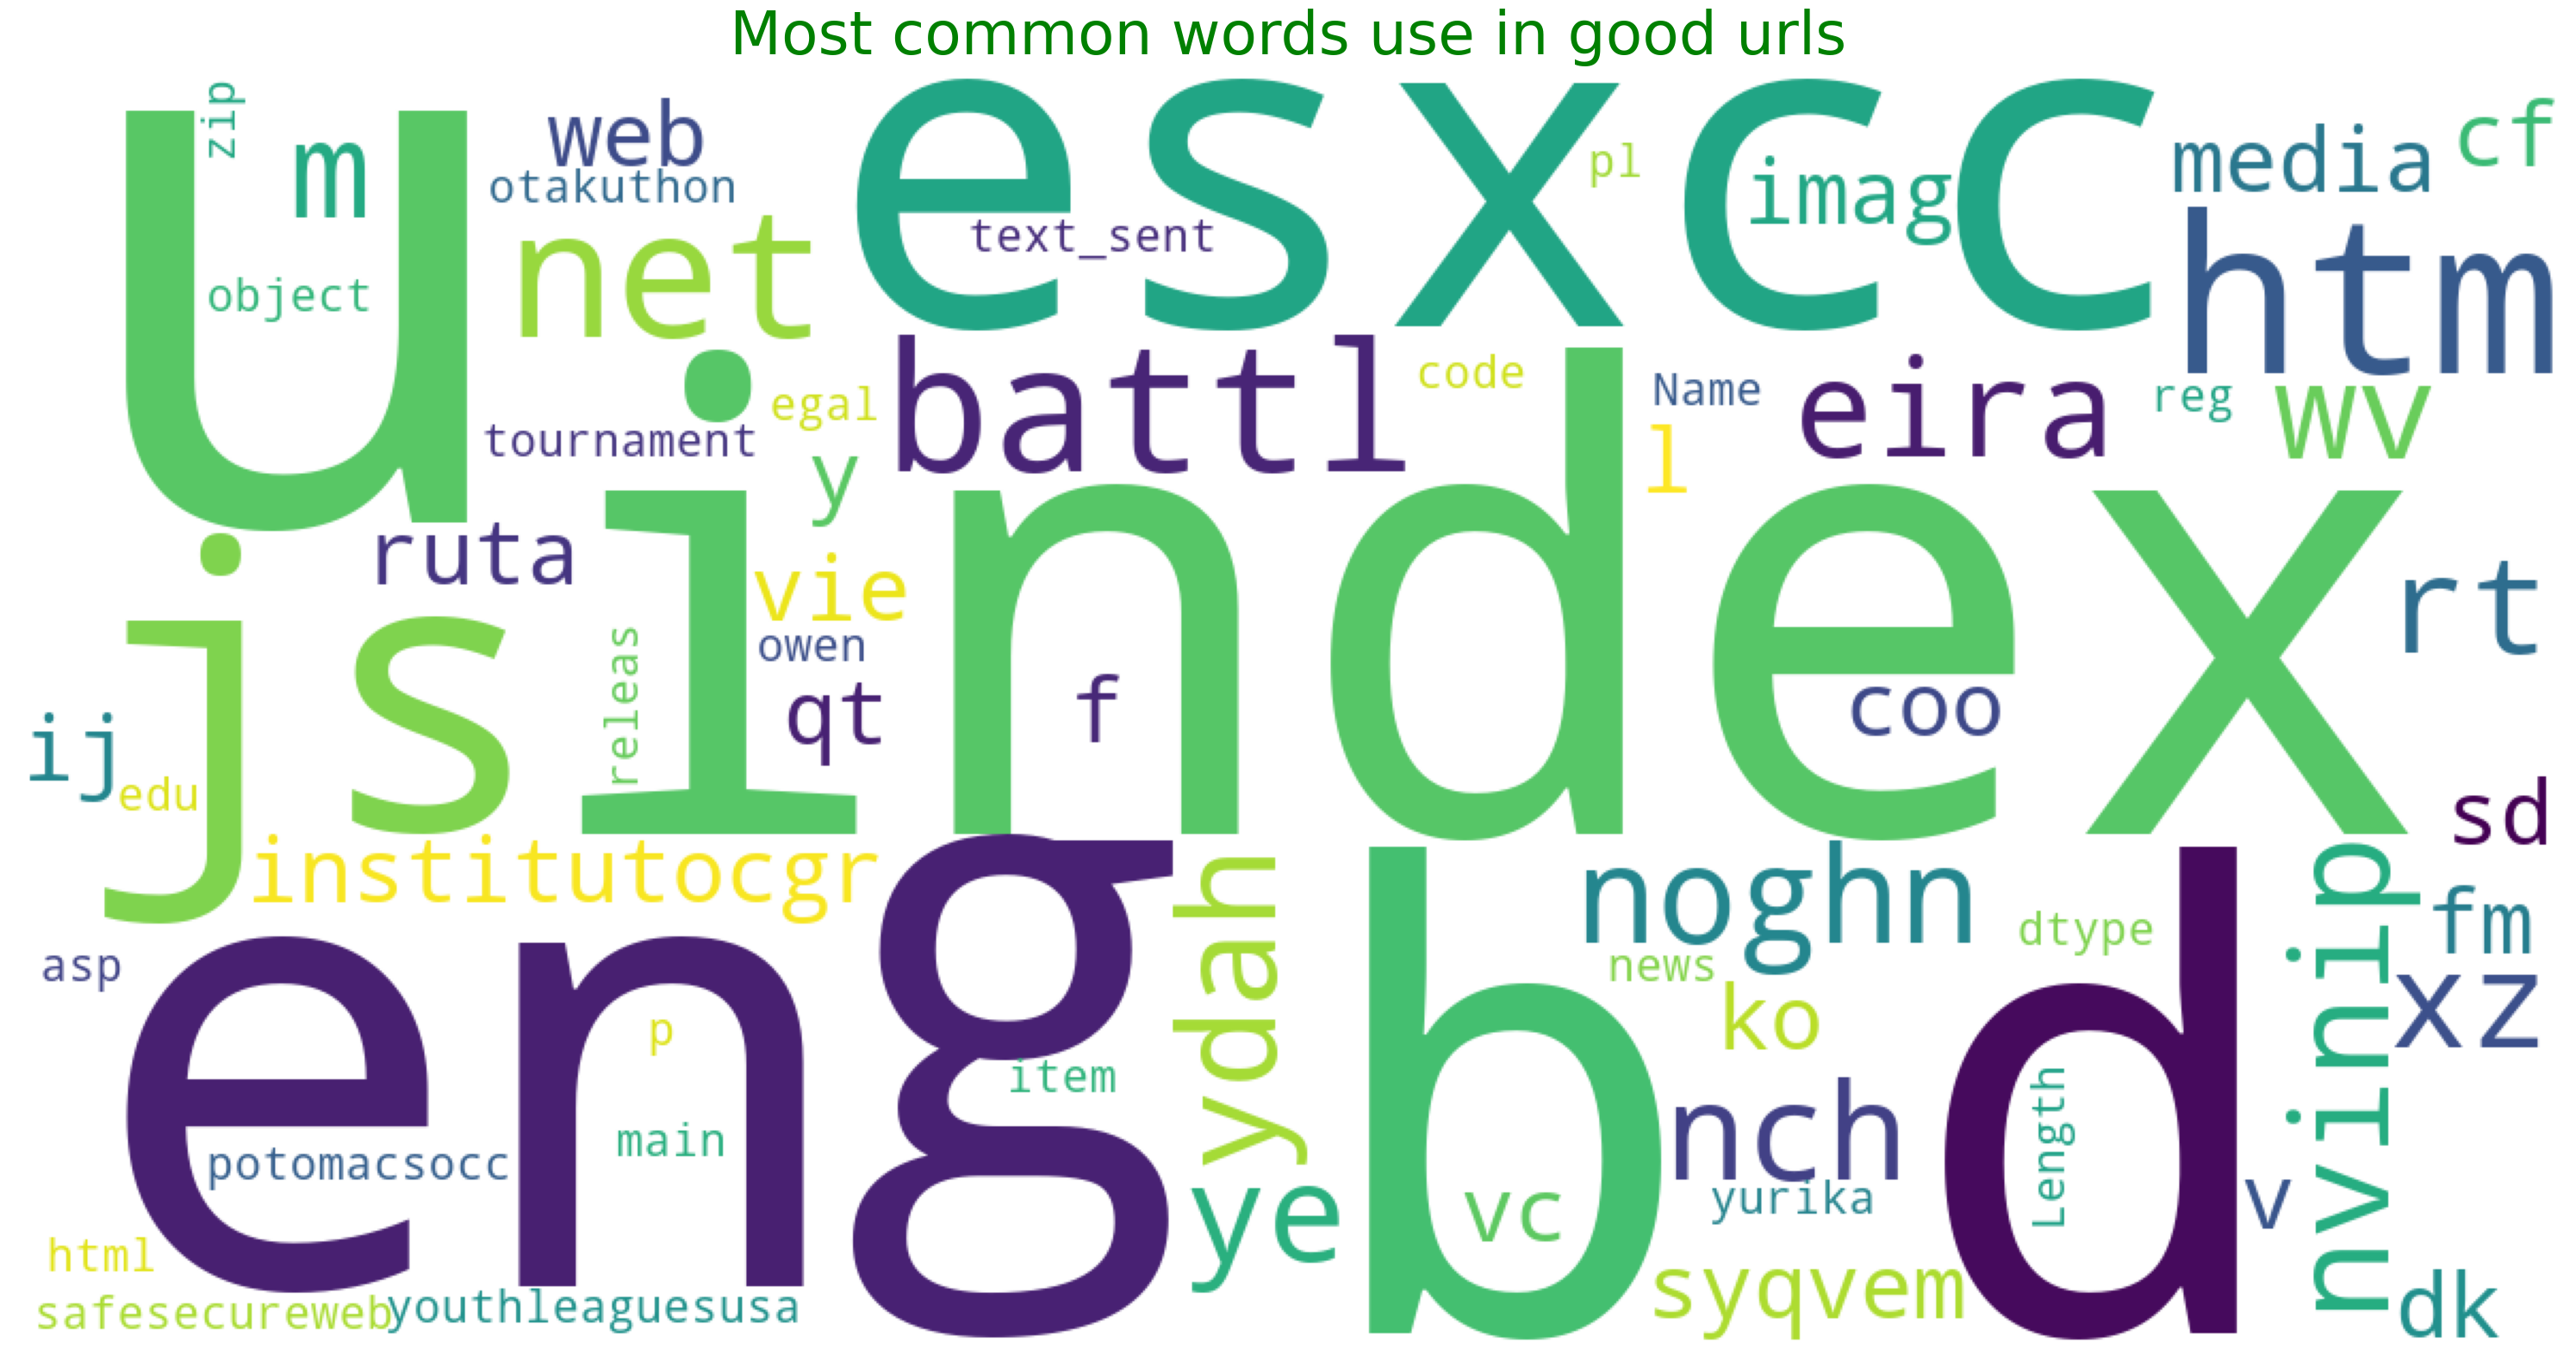

In [46]:
# 将所有正常URL的文本拼接成一个长字符串（作为词云的输入文本）
common_text = str(data)
# 读取星形掩码图片（词云会以星形轮廓显示）
# common_mask = np.array(Image.open(d+'cloud.png'))
# 调用函数生成词云，标题为“正常URL中最常见的单词”
plot_wordcloud(common_text, None, max_words=400, max_font_size=120, 
               title = 'Most common words use in good urls', title_size=50)

In [47]:
data = bad_sites.text_sent
data.reset_index(drop=True, inplace=True)

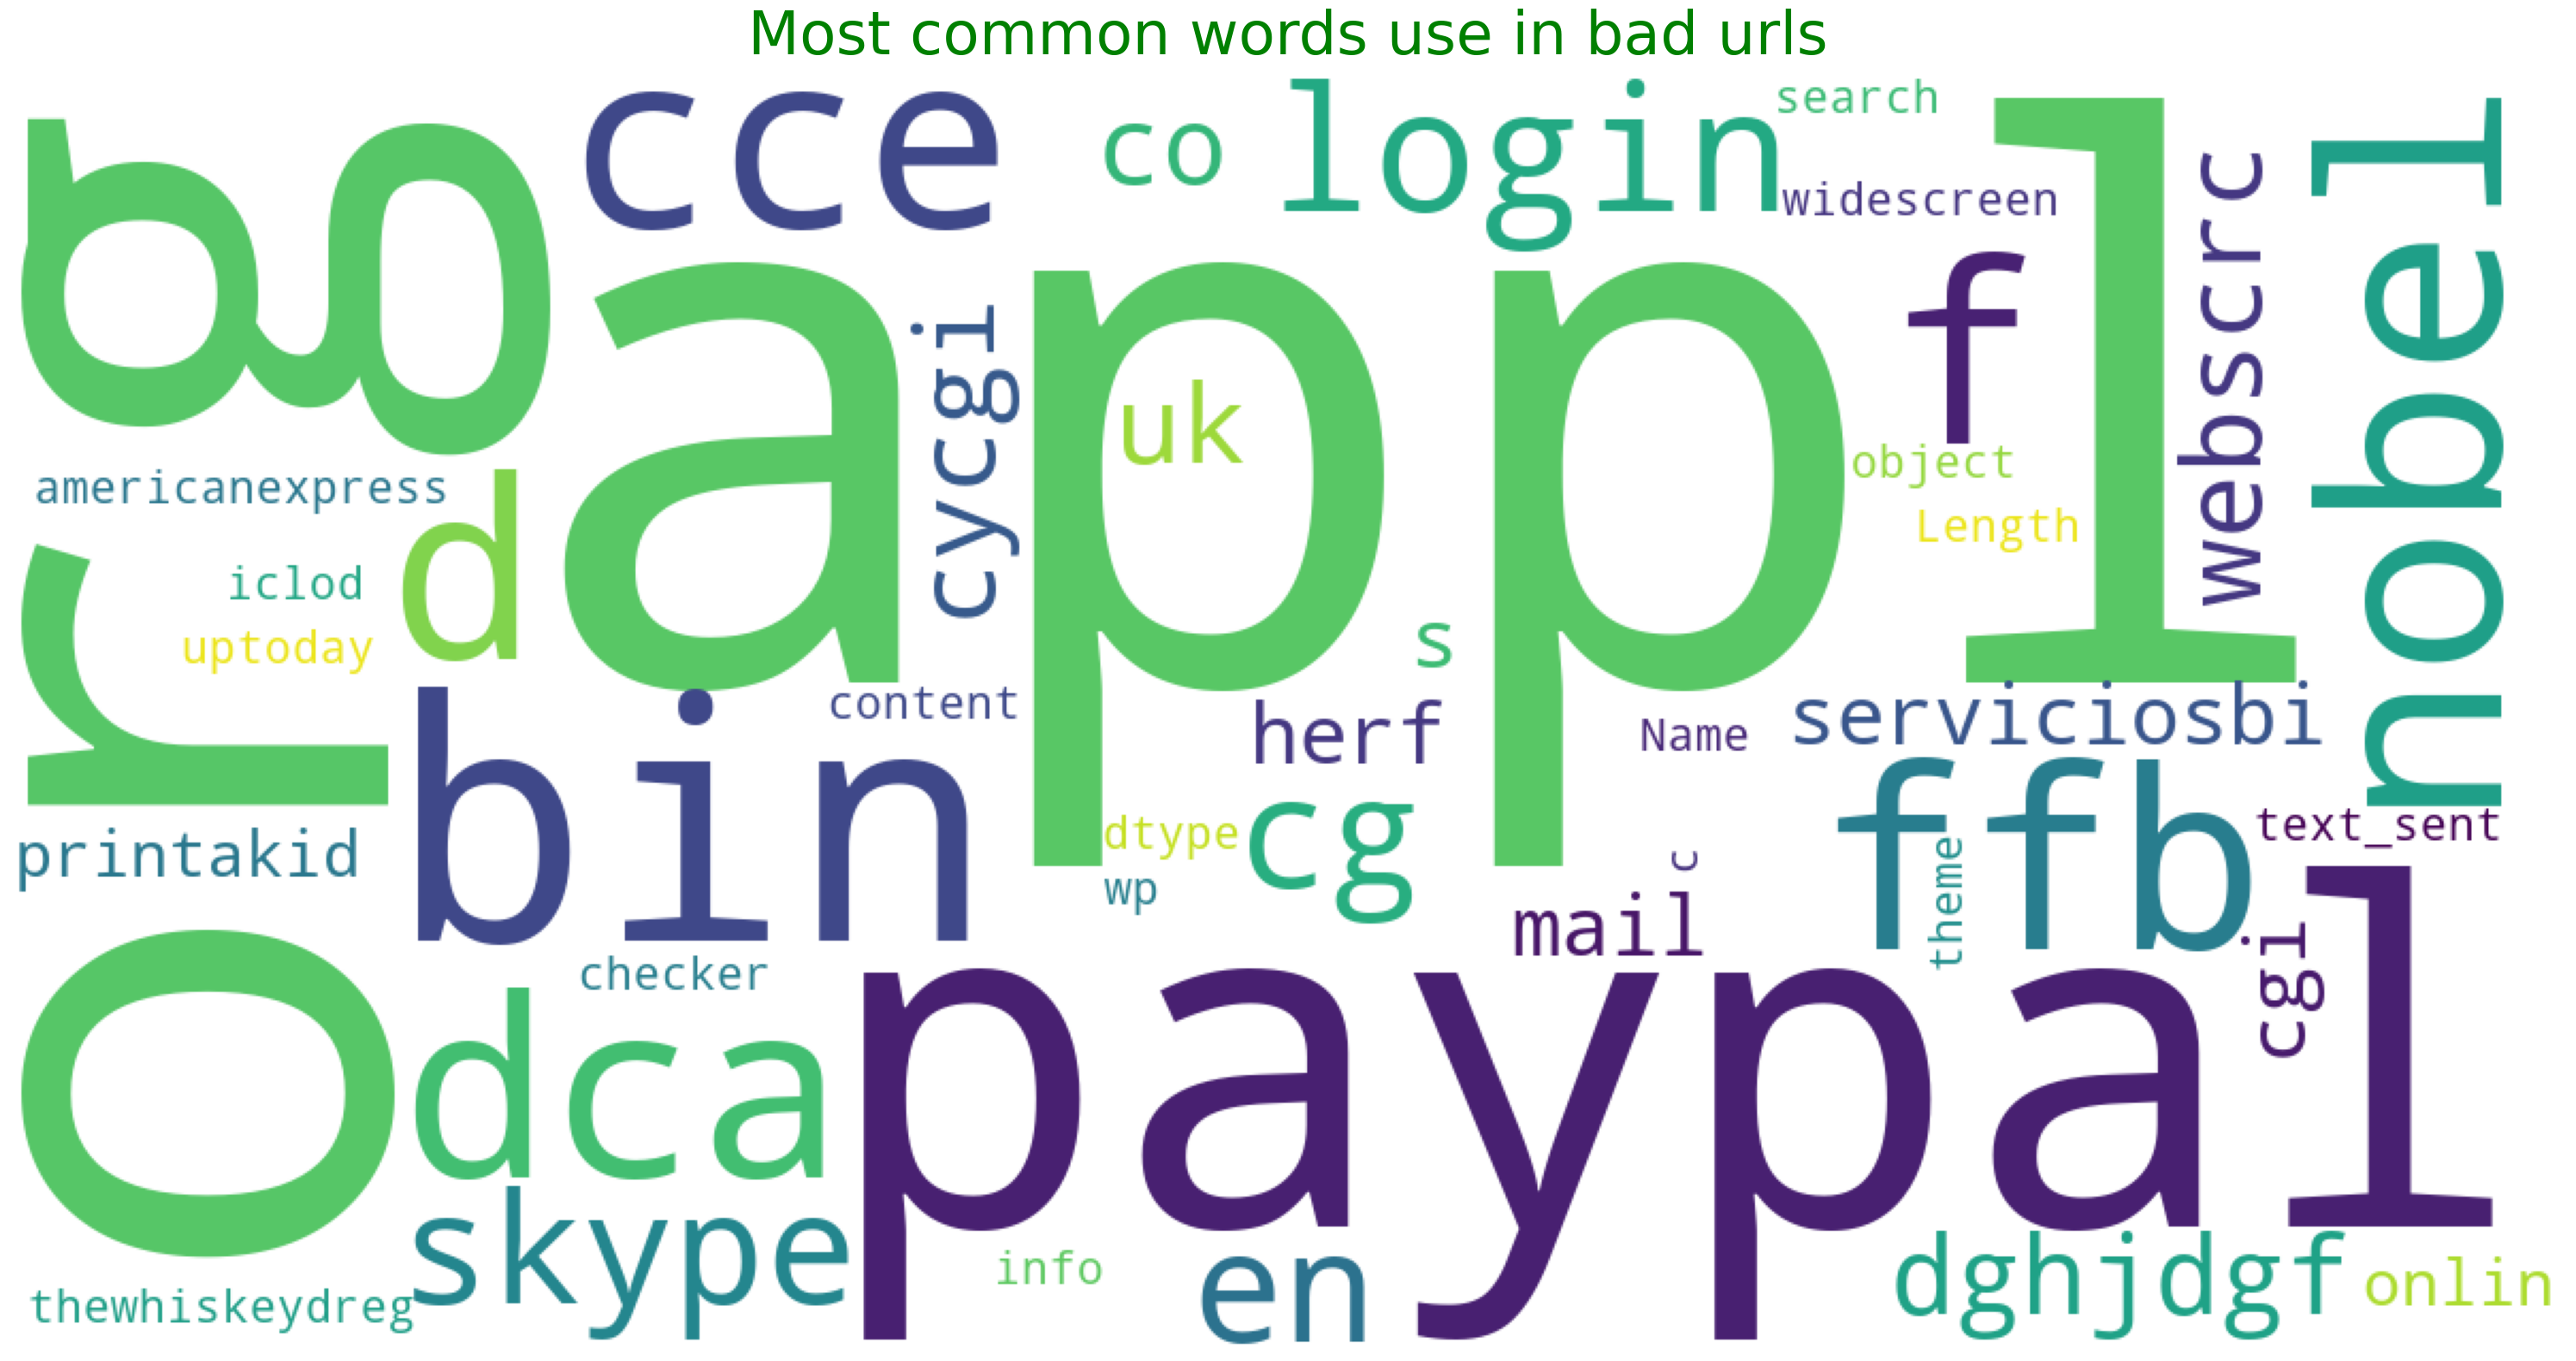

In [49]:
common_text = str(data)
# common_mask = np.array(Image.open(d+'comment.png'))
plot_wordcloud(common_text, None, max_words=400, max_font_size=120, 
               title = 'Most common words use in bad urls', title_size=50)

### 创建模型
#### CountVectorizer
* CountVectorizer 用于将文本语料库转换为术语/标记计数的向量。
* 将预处理后的文本（URL 词干化字符串）转换为机器学习模型可识别的数值特征矩阵

In [50]:
#create cv object
cv = CountVectorizer()

In [ ]:
help(CountVectorizer())

In [ ]:
# 转换所有经过分词和词干处理的文本 text_sent 这一列
feature = cv.fit_transform(phish_data.text_sent)

In [53]:
# 将稀疏矩阵转换为数组以打印转换后的要素
feature[:5].toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

#### * Spliting the data 

In [54]:
# 将特征数据和标签数据划分为训练集和测试集
# train_test_split：是 scikit-learn 库（sklearn.model_selection）中的函数，用于随机划分数据集为 “训练集”（用于模型学习）和 “测试集”（用于模型评估）。
trainX, testX, trainY, testY = train_test_split(feature, phish_data.Label)

### 逻辑回归算法
* 逻辑回归
* 逻辑回归是一种机器学习分类算法，用于预测分类因变量的概率。在逻辑回归中，因变量是一个二元变量，其数据编码为1（是，成功等）或0（否，失败等）。换句话说，逻辑回归模型将P(Y=1)预测为X的函数。

In [55]:
# create lr object
lr = LogisticRegression()

In [56]:
lr.fit(trainX,trainY)

LogisticRegression()

In [57]:
lr.score(testX,testY)

0.9636296118307521

**逻辑回归给出了96%的准确率，现在我们将分数存储在dict中，看看哪个模型表现最好.**

In [58]:
Scores_ml = {}
Scores_ml['Logistic Regression'] = np.round(lr.score(testX,testY),2)

* 准确率（Accuracy）：模型预测正确的样本数占总样本数的比例（正确预测数 / 总样本数）。
* 训练集准确率：反映模型对训练数据的 “学习效果”（是否能记住训练样本的模式）。
* 测试集准确率：反映模型对 “未见过的数据” 的 “泛化能力”（实际应用中能否准确预测新 URL）。
* 理想情况：两者接近且都较高（若训练准确率远高于测试准确率，可能存在过拟合）。

训练集准确率 : 0.9776752449582412
测试集准确率 : 0.9636296118307521

分类报告

              precision    recall  f1-score   support

         Bad       0.90      0.97      0.93     36690
        Good       0.99      0.96      0.97    100647

    accuracy                           0.96    137337
   macro avg       0.95      0.96      0.95    137337
weighted avg       0.97      0.96      0.96    137337


混淆矩阵


<Axes: >

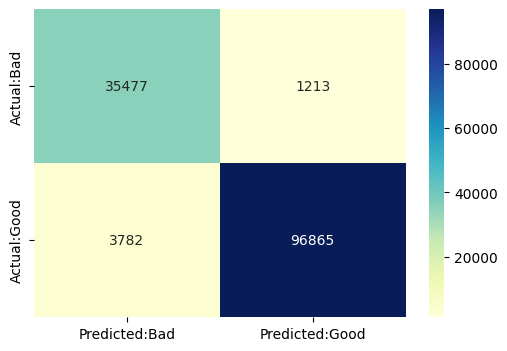

In [59]:
print('训练集准确率 :',lr.score(trainX,trainY))
print('测试集准确率 :',lr.score(testX,testY))
# 混淆矩阵：是分类模型评估的核心工具，展示 “预测标签” 与 “实际标签” 的对应关系
# 包含 4 个关键指标（假设Bad= 钓鱼 URL，Good= 正常 URL）：
# Actual:Bad行 & Predicted:Bad列：真阳性（TP）—— 实际是钓鱼 URL，模型正确预测为钓鱼（正确）。
# Actual:Bad行 & Predicted:Good列：假阴性（FN）—— 实际是钓鱼 URL，模型错误预测为正常（漏检，风险高）。
# Actual:Good行 & Predicted:Bad列：假阳性（FP）—— 实际是正常 URL，模型错误预测为钓鱼（误判，影响体验）。
# Actual:Good行 & Predicted:Good列：真阴性（TN）—— 实际是正常 URL，模型正确预测为正常（正确）。
con_mat = pd.DataFrame(confusion_matrix(lr.predict(testX), testY),
            columns = ['Predicted:Bad', 'Predicted:Good'],
            index = ['Actual:Bad', 'Actual:Good'])


print('\n分类报告\n')
# 精确率（Precision）：预测为某类的样本中，实际确实是该类的比例（TP / (TP + FP)）。例如Bad的精确率 =“预测为钓鱼且实际是钓鱼” 的比例，反映模型 “少误判正常 URL” 的能力。
# 召回率（Recall）：实际是某类的样本中，被模型正确预测的比例（TP / (TP + FN)）。例如Bad的召回率 =“实际是钓鱼且被正确预测” 的比例，反映模型 “少漏检钓鱼 URL” 的能力。
# F1 分数（F1-score）：精确率和召回率的调和平均（2*(精确率*召回率)/(精确率+召回率)），综合两者评估（避免单一指标偏差）。
# 支持度（Support）：该类别的实际样本数量（如Bad的 support = 测试集中实际钓鱼 URL 的总数）。
print(classification_report(lr.predict(testX), testY,
                            target_names =['Bad','Good']))

# 可视化混淆矩阵（热力图）
print('\n混淆矩阵')
plt.figure(figsize= (6,4))
sns.heatmap(con_mat, annot = True,fmt='d',cmap="YlGnBu")

1. 整体准确率（Accuracy）
   1. 训练集准确率～97.77%，测试集准确率～96.36%：
   2. 两者差距较小（仅约 1.4%），说明模型没有明显过拟合（未过度 “死记” 训练数据），泛化能力较强，在未见过的新 URL 上也能保持稳定表现。
   3. 整体准确率超过 96%，属于高水准，说明模型整体分类能力可靠。
2. 分类报告细节分析（核心关注 “Bad” 类，即钓鱼 URL）
   1. “Bad” 类（钓鱼 URL）
      1. 召回率（Recall）97%：
         1. 最重要的指标！表示 “实际是钓鱼 URL 的样本中，97% 被模型正确识别出来”，漏检率仅 3%。
      2. 精确率（Precision）90%：
         1. 表示 “模型预测为钓鱼 URL 的样本中，90% 确实是钓鱼 URL”，误判率 10%（即 10% 被预测为钓鱼的其实是正常 URL）。
      3. F1 分数 93%：综合精确率和召回率，表现优秀，说明模型在 “抓钓鱼” 和 “少误判” 之间平衡得很好。
   2. “Good” 类（正常 URL）
      1. 精确率 99%：几乎不会把正常 URL 误判为钓鱼（误判率仅 1%），用户几乎不会遇到 “正常网站被拦截” 的问题，体验极佳。
      2. 召回率 96%：96% 的正常 URL 被正确识别，极少数正常 URL 被误判，表现稳定。
      3. F1 分数 97%：综合表现接近完美，说明模型对正常 URL 的识别非常可靠。
3. 数据平衡性与模型适应性
   1. 从支持度（support）看：测试集中 “Good” 类（100647 条）远多于 “Bad” 类（36690 条），数据存在一定不平衡（正常 URL 占比更高）。
   2. 但模型在少数类（“Bad” 类）上仍保持了 97% 的高召回率，说明模型没有因数据不平衡而 “忽视” 钓鱼 URL，对少数类的识别能力强，这是非常关键的优势。
4. 总结：模型整体表现优秀，尤其在钓鱼检测的核心目标（“尽可能抓住钓鱼 URL，同时少误判正常 URL”）上达成了很好的平衡：


### 多项式朴素贝叶斯分类算法
* 将多项式朴素贝叶斯应用于自然语言处理问题。朴素贝叶斯分类算法是一类基于贝叶斯定理的概率算法，其“朴素”假设是每对特征之间条件独立。

In [60]:
# create mnb object
mnb = MultinomialNB()

In [61]:
mnb.fit(trainX,trainY)

MultinomialNB()

In [62]:
mnb.score(testX,testY)

0.957811805995471

**朴素贝叶斯分类算法有 95% 的准确率**  

In [63]:
Scores_ml['MultinomialNB'] = np.round(mnb.score(testX,testY),2)

训练集准确率 : 0.9738816385078967
测试集准确率 : 0.957811805995471

分类报告

              precision    recall  f1-score   support

         Bad       0.91      0.94      0.93     38315
        Good       0.98      0.97      0.97     99022

    accuracy                           0.96    137337
   macro avg       0.94      0.95      0.95    137337
weighted avg       0.96      0.96      0.96    137337


混淆矩阵


<Axes: >

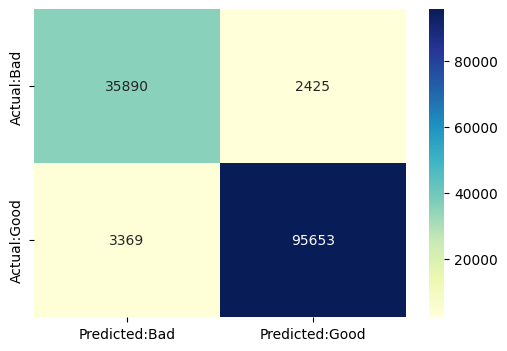

In [64]:
print('训练集准确率 :',mnb.score(trainX,trainY))
print('测试集准确率 :',mnb.score(testX,testY))
con_mat = pd.DataFrame(confusion_matrix(mnb.predict(testX), testY),
            columns = ['Predicted:Bad', 'Predicted:Good'],
            index = ['Actual:Bad', 'Actual:Good'])


print('\n分类报告\n')
print(classification_report(mnb.predict(testX), testY,
                            target_names =['Bad','Good']))

print('\n混淆矩阵')
plt.figure(figsize= (6,4))
sns.heatmap(con_mat, annot = True,fmt='d',cmap="YlGnBu")

<Axes: xlabel='None', ylabel='Accuracy'>

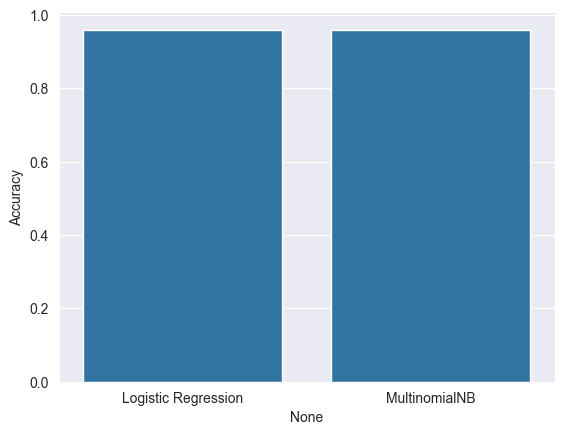

In [67]:
acc = pd.DataFrame.from_dict(Scores_ml,orient='index',columns=['Accuracy'])
sns.set_style('darkgrid')
sns.barplot(x=acc.index,y=acc.Accuracy)

**因此，逻辑回归是最佳拟合模型，现在我们使用逻辑回归制作sklearn管道**
* make_pipeline：scikit-learn 的工具函数，用于将多个处理步骤 “串联” 成一个管道（Pipeline），确保特征提取和模型训练的流程自动化，且避免数据泄露（如用训练集拟合的特征提取参数，会自动应用到测试集）。
* 输入原始 URL 文本 → CountVectorizer（分词→过滤停用词→生成词频特征） → LogisticRegression（用特征训练模型并预测）。

In [68]:
pipeline_ls = make_pipeline(CountVectorizer(tokenizer = RegexpTokenizer(r'[A-Za-z]+').tokenize,stop_words='english'), LogisticRegression())
##(r'\b(?:http|ftp)s?://\S*\w|\w+|[^\w\s]+') ([a-zA-Z]+)([0-9]+)  -- 这些效果不好，对分类贡献较小，过度保留反而会引入噪音，降低模型准确率。 

In [69]:
# 直接用原始 URL 文本（phish_data.URL）作为输入（无需手动预处理，管道会自动处理），划分训练集（用于拟合管道）和测试集（用于评估）。
trainX, testX, trainY, testY = train_test_split(phish_data.URL, phish_data.Label)

In [70]:
# 用训练集 URL 和标签拟合管道（内部先对训练 URL 做分词→词频特征，再训练逻辑回归）。
pipeline_ls.fit(trainX,trainY)

Pipeline(steps=[('countvectorizer',
                 CountVectorizer(stop_words='english',
                                 tokenizer=<bound method RegexpTokenizer.tokenize of RegexpTokenizer(pattern='[A-Za-z]+', gaps=False, discard_empty=True, flags=re.UNICODE|re.MULTILINE|re.DOTALL)>)),
                ('logisticregression', LogisticRegression())])

In [71]:
# 计算得分
pipeline_ls.score(testX,testY) 

0.9659378026314831

训练集准确率 : 0.9804979988301227
测试集准确率 : 0.9659378026314831

分类报告

              precision    recall  f1-score   support

         Bad       0.91      0.97      0.94     36920
        Good       0.99      0.97      0.98    100417

    accuracy                           0.97    137337
   macro avg       0.95      0.97      0.96    137337
weighted avg       0.97      0.97      0.97    137337


混淆矩阵


<Axes: >

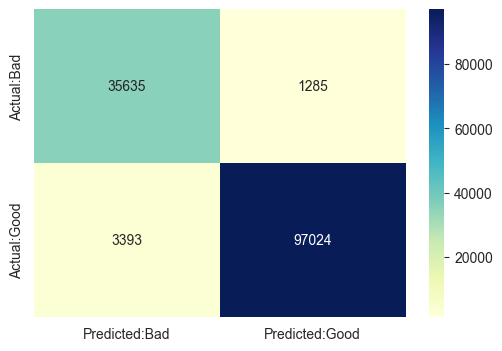

In [72]:
print('训练集准确率 :',pipeline_ls.score(trainX,trainY))
print('测试集准确率 :',pipeline_ls.score(testX,testY))
con_mat = pd.DataFrame(confusion_matrix(pipeline_ls.predict(testX), testY),
            columns = ['Predicted:Bad', 'Predicted:Good'],
            index = ['Actual:Bad', 'Actual:Good'])


print('\n分类报告\n')
print(classification_report(pipeline_ls.predict(testX), testY,
                            target_names =['Bad','Good']))

print('\n混淆矩阵')
plt.figure(figsize= (6,4))
sns.heatmap(con_mat, annot = True,fmt='d',cmap="YlGnBu")

In [73]:
pickle.dump(pipeline_ls,open('phishing.pkl','wb'))

In [74]:
loaded_model = pickle.load(open('phishing.pkl', 'rb'))
result = loaded_model.score(testX,testY)
print(result)

0.9659378026314831


**我们的准确率达到了98%。对于机器来说，能够检测出恶意URL的准确率是一个非常高的值。接下来看看模型的预测效果如何**

* **钓鱼站点**
* yeniik.com.tr/wp-admin/js/login.alibaba.com/login.jsp.php
* fazan-pacir.rs/temp/libraries/ipad
* www.tubemoviez.exe
* svision-online.de/mgfi/administrator/components/com_babackup/classes/fx29id1.txt

* **非钓鱼站点**
* www.youtube.com/
* youtube.com/watch?v=qI0TQJI3vdU
* www.retailhellunderground.com/
* restorevisioncenters.com/html/technology.html

In [ ]:
predict_bad = ['yeniik.com.tr/wp-admin/js/login.alibaba.com/login.jsp.php','fazan-pacir.rs/temp/libraries/ipad','tubemoviez.exe','svision-online.de/mgfi/administrator/components/com_babackup/classes/fx29id1.txt']
predict_good = ['youtube.com/','youtube.com/watch?v=qI0TQJI3vdU','retailhellunderground.com/','restorevisioncenters.com/html/technology.html']
loaded_model = pickle.load(open('phishing.pkl', 'rb'))
# predict_bad = vectorizers.transform(predict_bad)
# predict_good = vectorizer.transform(predict_good)
result = loaded_model.predict(predict_bad)
result2 = loaded_model.predict(predict_good)
print(result)
print("*"*30)
print(result2)

['bad' 'bad' 'bad' 'bad']
******************************
['good' 'good' 'good' 'good']
